Sumber dataset : https://www.kaggle.com/datasets/nelakurthisudheer/dataset-for-predicting-watering-the-plants

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Membaca dataset
dataset = pd.read_csv("TARP.csv")

In [ ]:
dataset.head()

,Soil Moisture,Temperature,Soil Humidity,Time,Air temperature (C),Wind speed (Km/h),Air humidity (%),Wind gust (Km/h),Pressure (KPa),ph,rainfall,N,P,K,Status
0,54,22,70,21,19.52,2.13,55.04,6.30,101.50,6.502985,202.935536,90.0,42.0,43.0,ON
1,12,20,40,104,19.49,2.01,55.17,10.46,101.50,7.038096,226.655537,85.0,58.0,41.0,OFF
2,34,26,35,62,19.47,1.90,55.30,14.63,101.51,7.840207,263.964248,60.0,55.0,44.0,ON
3,7,44,44,93,19.54,2.28,54.20,16.08,101.51,6.980401,242.864034,74.0,35.0,40.0,OFF
4,50,38,23,92,19.61,2.66,53.09,17.52,101.51,7.628473,262.717340,78.0,42.0,42.0,OFF


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Soil Moisture        100000 non-null  int64  
 1   Temperature          100000 non-null  int64  
 2    Soil Humidity       100000 non-null  int64  
 3   Time                 100000 non-null  int64  
 4   Air temperature (C)  23995 non-null   float64
 5   Wind speed (Km/h)    23995 non-null   float64
 6   Air humidity (%)     23995 non-null   float64
 7   Wind gust (Km/h)     23995 non-null   float64
 8   Pressure (KPa)       23995 non-null   float64
 9   ph                   2200 non-null    float64
 10  rainfall             2200 non-null    float64
 11  N                    2200 non-null    float64
 12  P                    2200 non-null    float64
 13  K                    2200 non-null    float64
 14  Status               100000 non-null  object 
dtypes: float64(10), in

In [ ]:
dataset.shape

(100000, 15)

In [ ]:
df = pd.DataFrame(dataset)

In [ ]:
#jumlah data yang null
df.isnull().sum()

,0
Soil Moisture,0
Temperature,0
Soil Humidity,0
Time,0
Air temperature (C),76005
Wind speed (Km/h),76005
Air humidity (%),76005
Wind gust (Km/h),76005
Pressure (KPa),76005
ph,97800


In [ ]:
#persentase jumlah data yang tidak null
df.notnull().mean()

,0
Soil Moisture,1.00000
Temperature,1.00000
Soil Humidity,1.00000
Time,1.00000
Air temperature (C),0.23995
Wind speed (Km/h),0.23995
Air humidity (%),0.23995
Wind gust (Km/h),0.23995
Pressure (KPa),0.23995
ph,0.02200


In [ ]:
#menghapus baris apa saja yang bernilai null
df = df.dropna(axis = 0 , how = "any" )
#jika menghapus waktu
#df = df.drop('Time', axis=1)

In [ ]:
le = LabelEncoder()
#melakukan label encoding pada kolom 'Status'
df['Status'] = le.fit_transform(df['Status'])

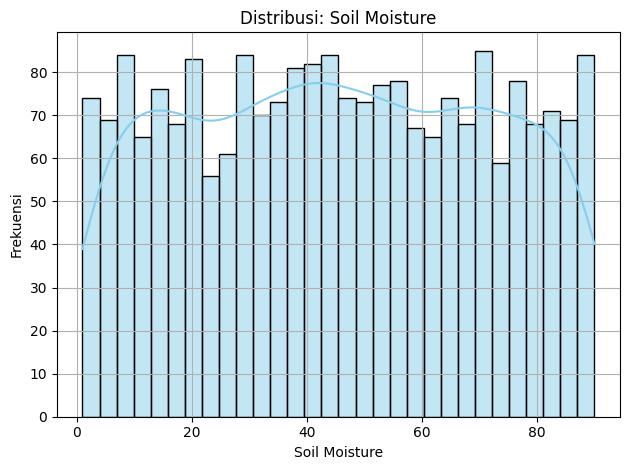

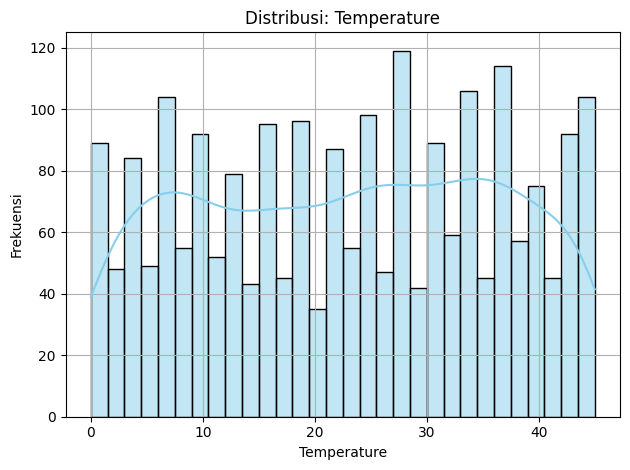

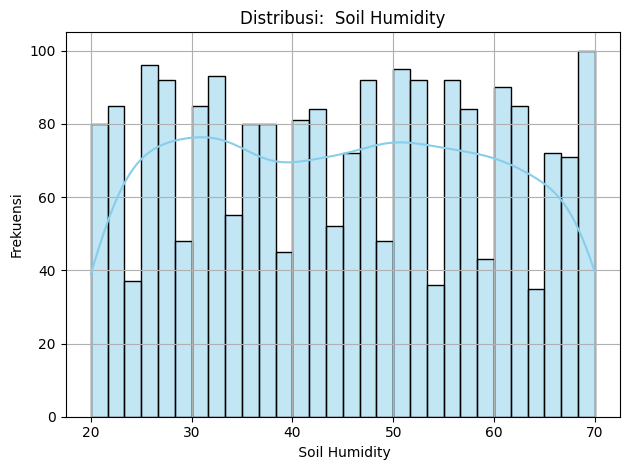

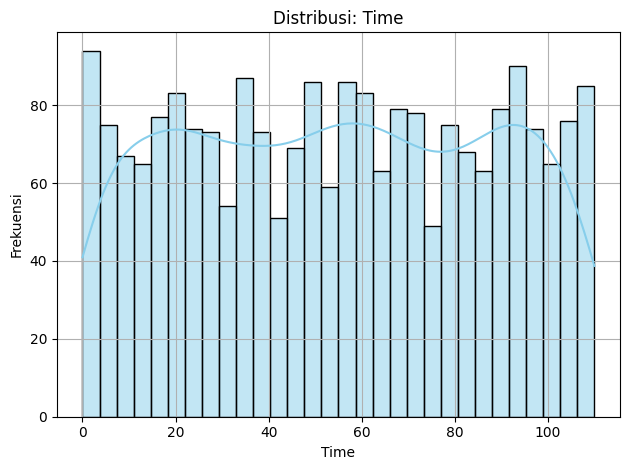

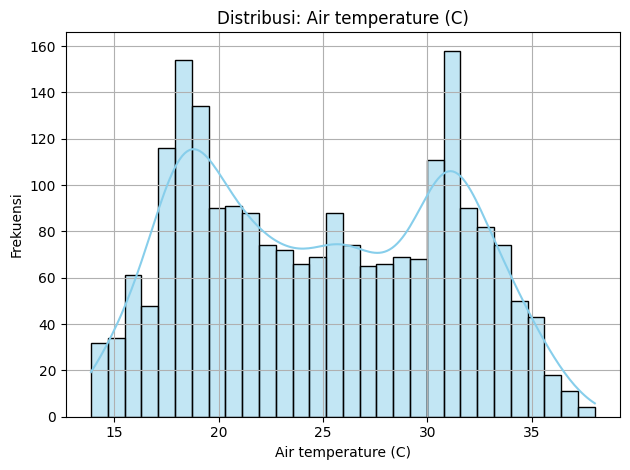

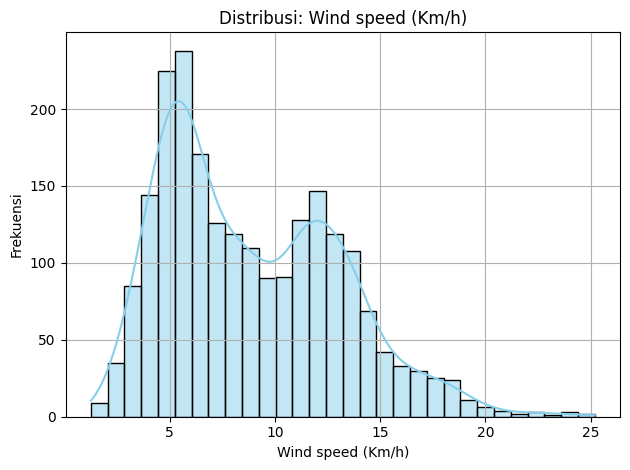

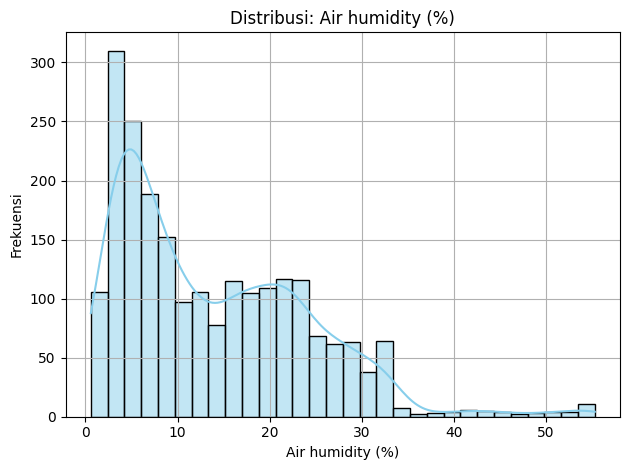

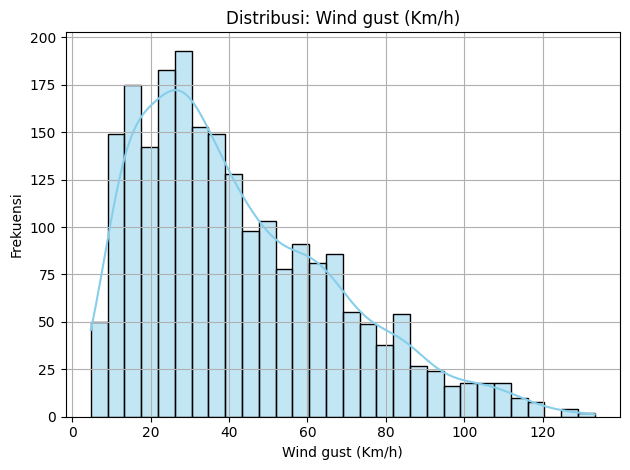

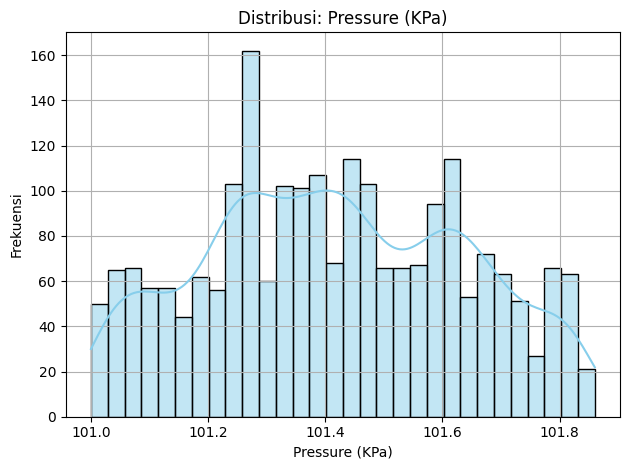

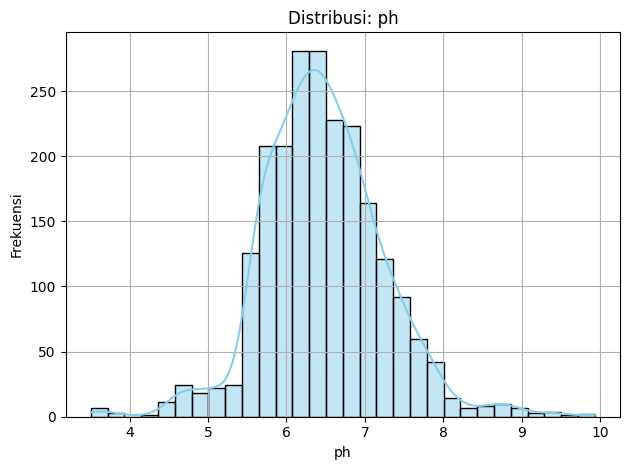

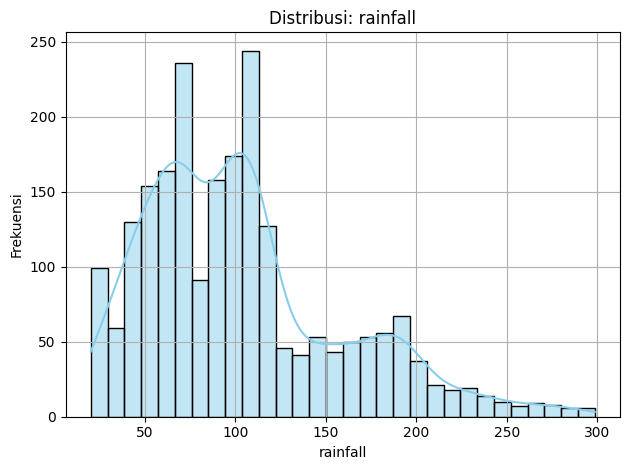

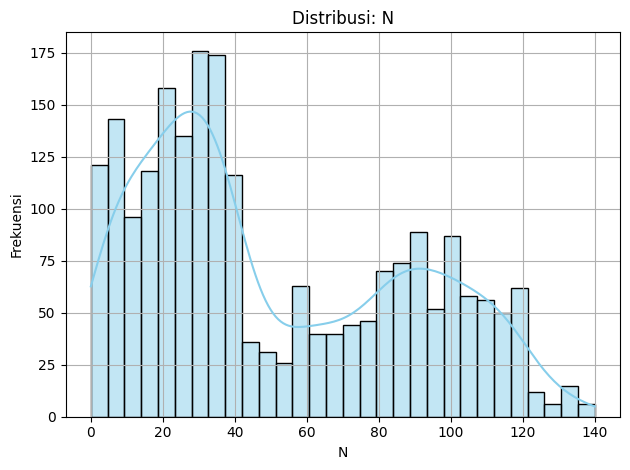

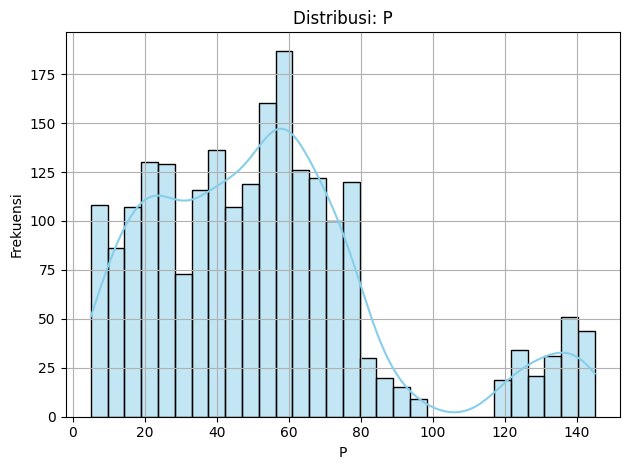

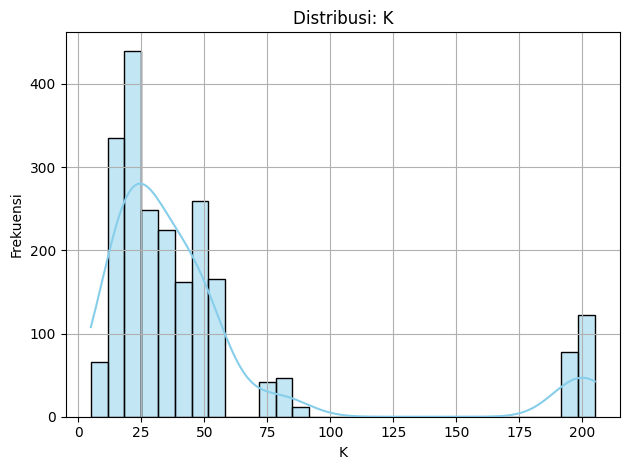

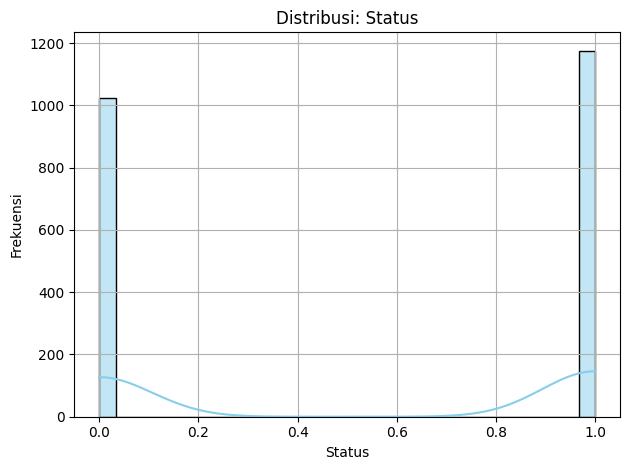

In [ ]:
# Visualisasi Histogram Semua Kolom Numerik dalam Satu Scroll
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    sns.histplot(df[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribusi: {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
df

,Soil Moisture,Temperature,Soil Humidity,Time,Air temperature (C),Wind speed (Km/h),Air humidity (%),Wind gust (Km/h),Pressure (KPa),ph,rainfall,N,P,K,Status
0,54,22,70,21,19.52,2.13,55.04,6.30,101.50,6.502985,202.935536,90.0,42.0,43.0,1
1,12,20,40,104,19.49,2.01,55.17,10.46,101.50,7.038096,226.655537,85.0,58.0,41.0,0
2,34,26,35,62,19.47,1.90,55.30,14.63,101.51,7.840207,263.964248,60.0,55.0,44.0,1
3,7,44,44,93,19.54,2.28,54.20,16.08,101.51,6.980401,242.864034,74.0,35.0,40.0,0
4,50,38,23,92,19.61,2.66,53.09,17.52,101.51,7.628473,262.717340,78.0,42.0,42.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,90,32,28,68,31.44,11.26,7.10,54.27,101.46,6.780064,177.774507,107.0,34.0,32.0,1
2196,41,21,48,42,31.47,12.02,7.05,58.54,101.45,6.086922,127.924610,99.0,15.0,27.0,1
2197,24,37,44,78,31.48,11.57,6.92,54.27,101.44,6.362608,173.322839,118.0,33.0,30.0,1
2198,10,15,22,62,31.48,11.12,6.79,50.00,101.43,6.758793,127.175293,117.0,32.0,34.0,1


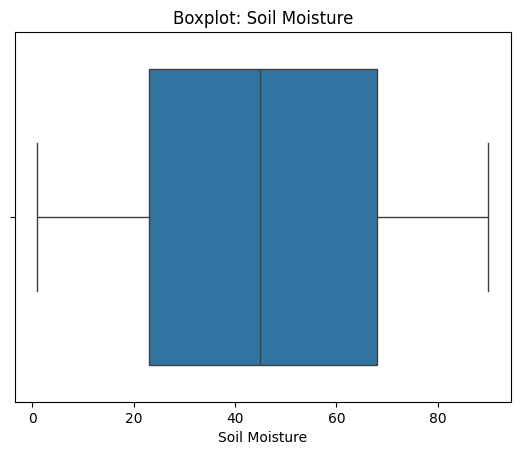

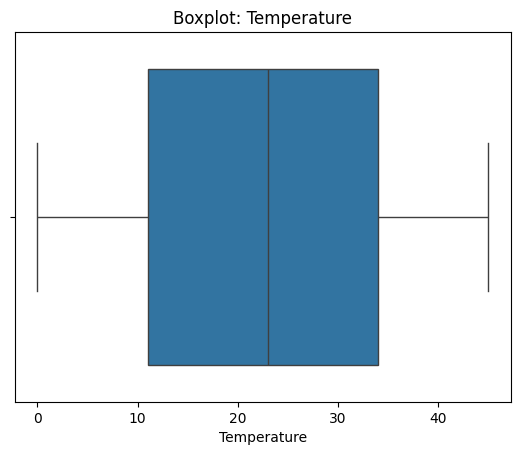

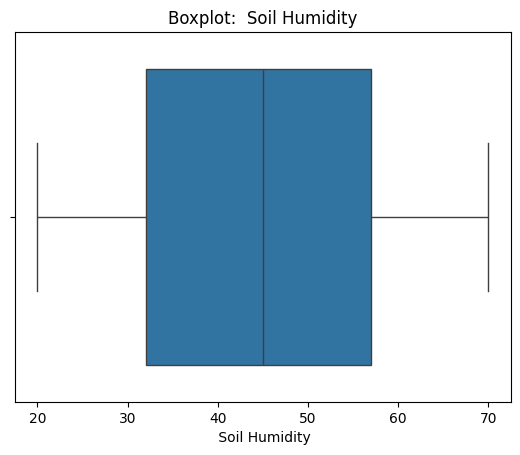

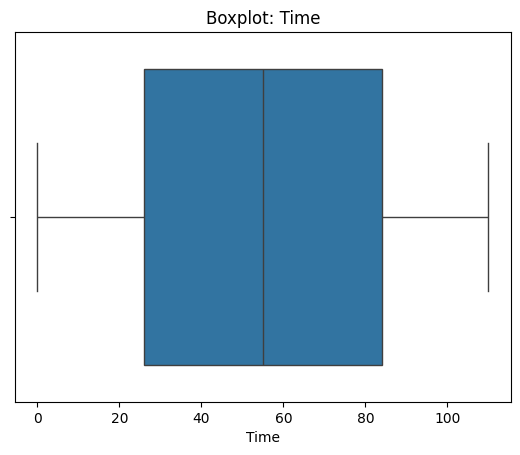

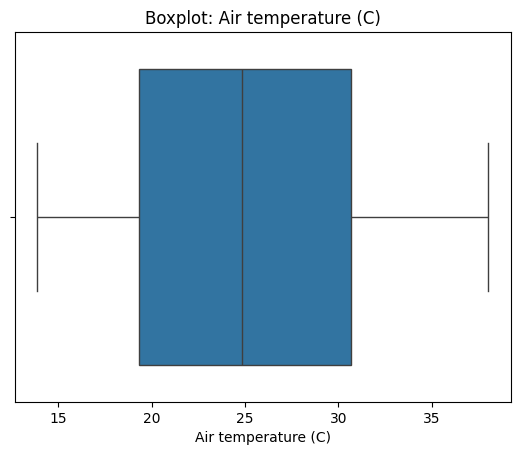

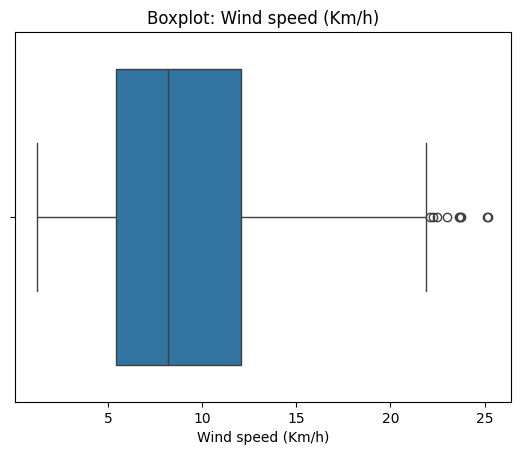

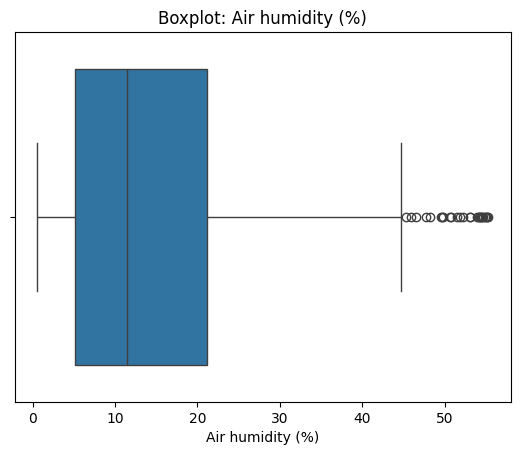

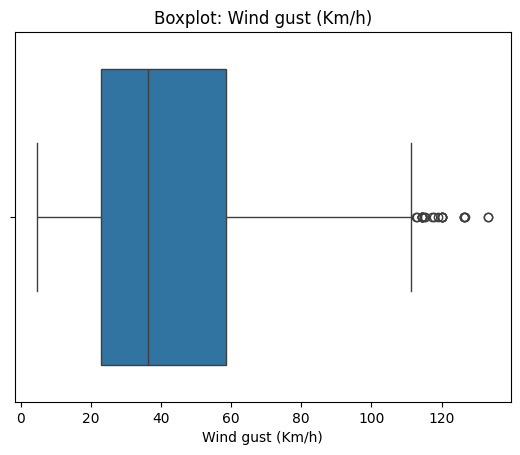

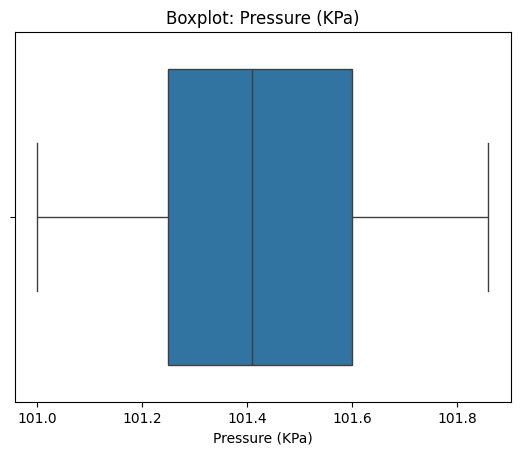

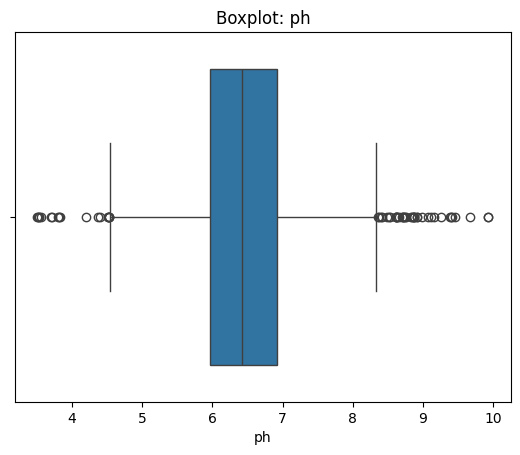

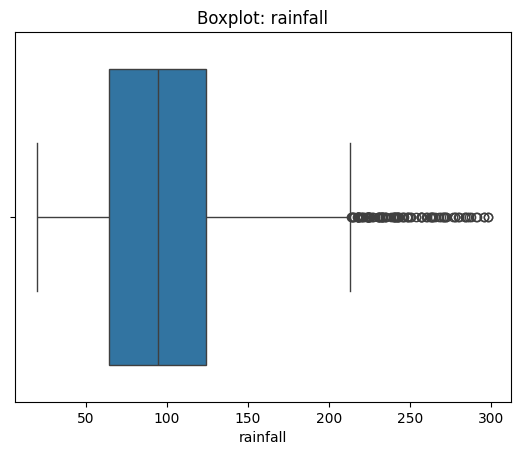

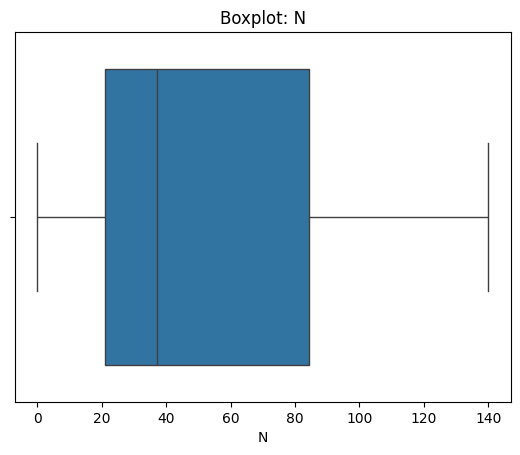

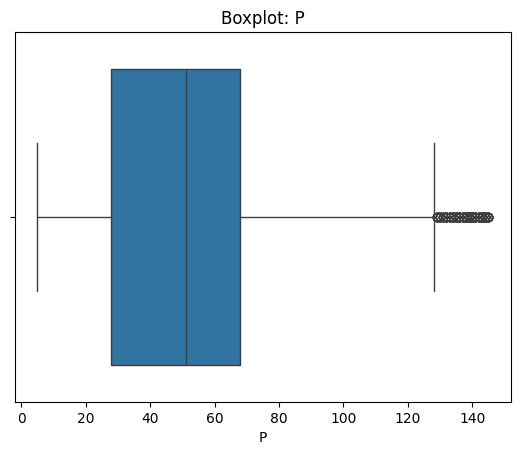

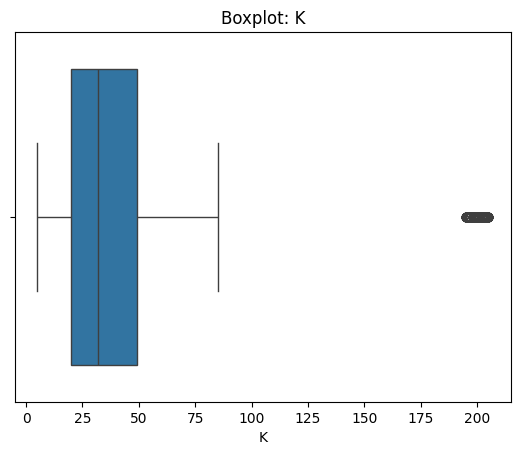

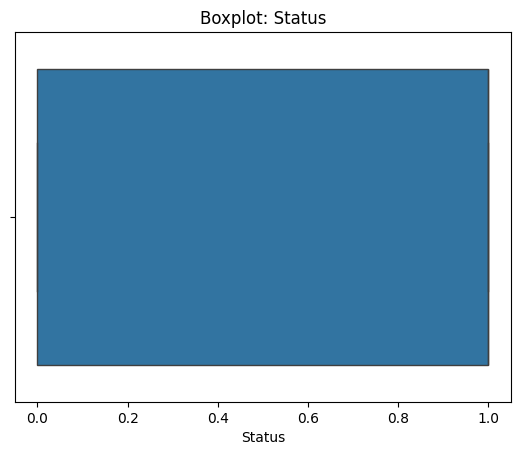

In [ ]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot: {col}")
    plt.show()


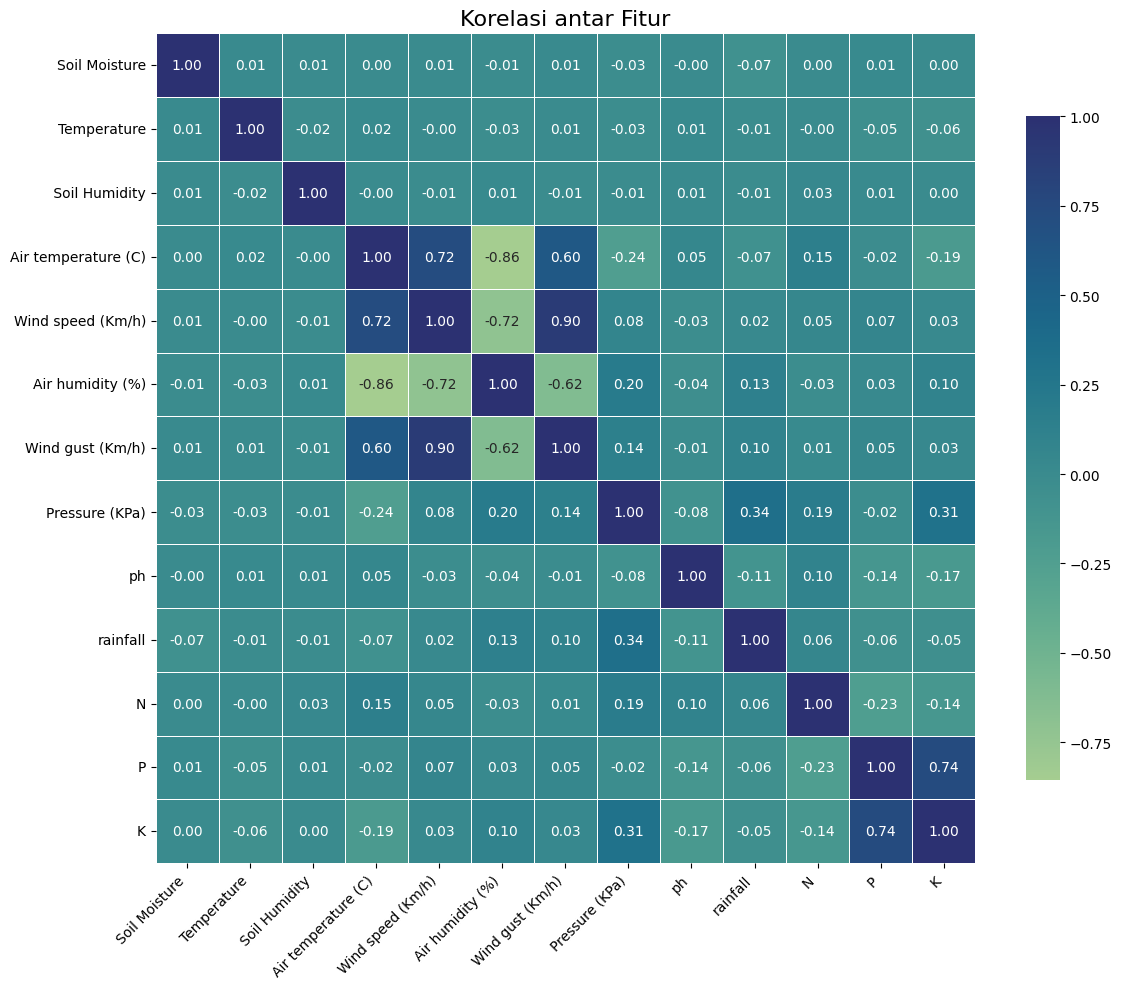

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

data = df[['Soil Moisture', 'Temperature',' Soil Humidity','Air temperature (C)','Wind speed (Km/h)','Air humidity (%)','Wind gust (Km/h)','Pressure (KPa)', 'ph' ,'rainfall' ,'N' ,'P','K']]
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation, cmap="crest", annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title("Korelasi antar Fitur", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Split features and target
X, y = df.drop('Status', axis=1), df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict and evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.8984848484848484


In [ ]:
y_pred

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,

In [ ]:
# Membuat dataframe khusus untuk data uji
result_df = X_test.copy()
result_df['Actual_Status'] = y_test.values
result_df['Predicted_Status'] = y_pred

# Menampilkan contoh hasil
result_df.head()

,Soil Moisture,Temperature,Soil Humidity,Time,Air temperature (C),Wind speed (Km/h),Air humidity (%),Wind gust (Km/h),Pressure (KPa),ph,rainfall,N,P,K,Actual_Status,Predicted_Status
1451,48,4,64,40,18.97,4.62,24.84,18.05,101.63,6.185053,26.308209,101.0,17.0,47.0,1,0
1334,63,34,52,77,30.79,12.87,4.68,51.06,101.29,6.259336,49.430510,98.0,8.0,51.0,1,1
1761,38,41,54,50,20.21,7.67,14.18,41.90,101.62,6.941497,114.778071,59.0,62.0,49.0,1,1
1735,75,45,69,86,23.26,6.68,8.77,36.90,101.70,6.825371,98.540477,44.0,60.0,55.0,1,1
1576,4,6,28,33,29.74,15.94,6.24,100.00,101.80,5.603413,118.604465,30.0,137.0,200.0,1,1


In [ ]:
result_df['Prob_ON'] = rf.predict_proba(X_test)[:, 1]  # probabilitas status ON

In [ ]:
result_df.to_csv("hasil_prediksi.csv", index=False) # Output hasil prediksi

In [ ]:
result_df.head()

,Soil Moisture,Temperature,Soil Humidity,Time,Air temperature (C),Wind speed (Km/h),Air humidity (%),Wind gust (Km/h),Pressure (KPa),ph,rainfall,N,P,K,Actual_Status,Predicted_Status,Prob_ON
1451,48,4,64,40,18.97,4.62,24.84,18.05,101.63,6.185053,26.308209,101.0,17.0,47.0,1,0,0.48
1334,63,34,52,77,30.79,12.87,4.68,51.06,101.29,6.259336,49.430510,98.0,8.0,51.0,1,1,0.78
1761,38,41,54,50,20.21,7.67,14.18,41.90,101.62,6.941497,114.778071,59.0,62.0,49.0,1,1,0.97
1735,75,45,69,86,23.26,6.68,8.77,36.90,101.70,6.825371,98.540477,44.0,60.0,55.0,1,1,0.86
1576,4,6,28,33,29.74,15.94,6.24,100.00,101.80,5.603413,118.604465,30.0,137.0,200.0,1,1,0.78


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89       308
           1       0.90      0.91      0.91       352

    accuracy                           0.90       660
   macro avg       0.90      0.90      0.90       660
weighted avg       0.90      0.90      0.90       660



- presisi : Seberapa banyak prediksi positif yang benar.

        Precision = TP / (TP + FP)

- Recall : Seberapa banyak data positif yang berhasil dikenali model.
        Recall = TP / (TP + FN)


- F1-Score : Rata-rata harmonis dari precision dan recall.

        F1 = 2 × (precision x recall) / (precision + recall)



- Support : Jumlah data aktual (jumlah instance di y_test) untuk masing-masing kelas.

In [ ]:
#Evaluate model
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f1_score(y_test, y_pred))

[[273  35]
 [ 32 320]]
0.9052333804809052


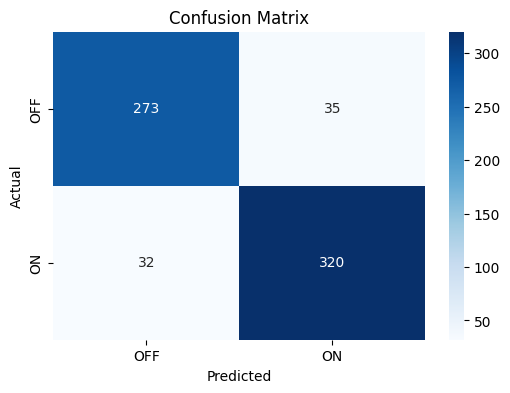

In [ ]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['OFF', 'ON'], yticklabels=['OFF', 'ON'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

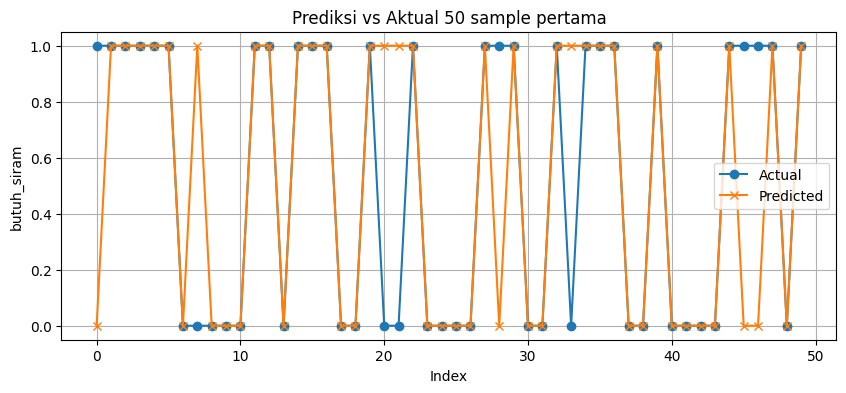

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(y_test.values[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title('Prediksi vs Aktual 50 sample pertama')
plt.xlabel('Index')
plt.ylabel('butuh_siram')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#Mengukur kualitas model klasifikasi (Random Forest) menggunakan ROC AUC Score.
from sklearn.metrics import roc_auc_score
proba = rf.predict_proba(X_test)[:, 1]
print(f"ROC AUC Score: {roc_auc_score(y_test, proba):.2f}")

ROC AUC Score: 0.95


Kode ini digunakan untuk mengevaluasi seberapa baik model Random Forest membedakan antara kelas ON dan OFF (dalam kasus prediksi penyiraman otomatis) berdasarkan probabilitas hasil prediksi.

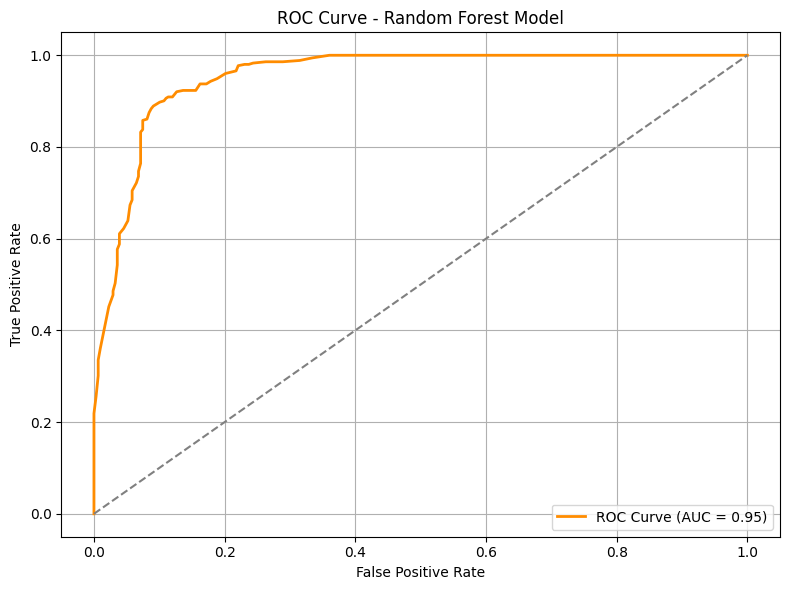

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, proba)
auc_score = roc_auc_score(y_test, proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-29-406862661.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')  # Plot bar chart


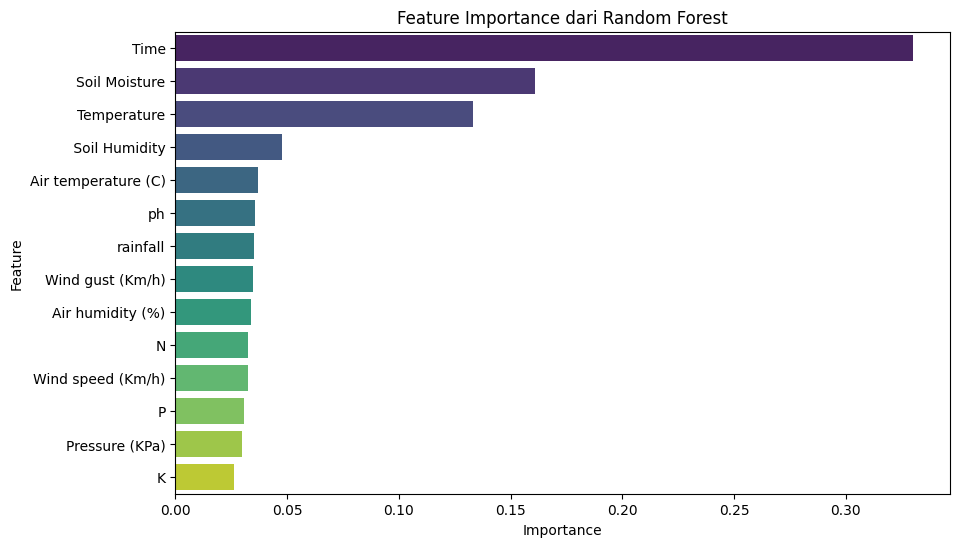

In [ ]:
importances = rf.feature_importances_        # Ambil skor kepentingan tiap fitur dari model Random Forest, fitur apa yang berpengaruh tinggi terhadap kinerja model
feat_names = X.columns                       # Ambil nama-nama fitur dari DataFrame
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})  # Gabungkan ke dalam DataFrame
feat_df = feat_df.sort_values(by='Importance', ascending=False)  # Urutkan dari yang paling penting

plt.figure(figsize=(10,6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')  # Plot bar chart
plt.title('Feature Importance dari Random Forest')
plt.show()

Ini menunjukkan bahwa fitur "Time" berpengaruh tinggi dalam kinerja prediksi model Random Forest. tanpa atribut "Time", akurasi model bisa saja lebih rendah

In [ ]:
# Inputan User
print("\n Masukkan nilai untuk masing-masing fitur berikut:\n")

# Daftar fitur yang dibutuhkan
feature_names = X.columns.tolist()
input_data = []

# Loop untuk meminta input user
for feature in feature_names:
    while True:
        try:
            value = float(input(f"{feature}: "))
            input_data.append(value)
            break
        except ValueError:
            print("Masukkan angka yang valid.")

# Konversi input ke DataFrame dengan nama kolom yang sesuai
user_df = pd.DataFrame([input_data], columns=feature_names)

# === Prediksi ===
pred = rf.predict(user_df)[0]
pred_label = le.inverse_transform([pred])[0]

print("\n=== HASIL PREDIKSI ===")

print(f"Status prediksi: {pred_label}")


 Masukkan nilai untuk masing-masing fitur berikut:

Soil Moisture: 50
Temperature: 30
 Soil Humidity: 40
Time: 50
Air temperature (C): 22
Wind speed (Km/h): 50
Air humidity (%): 46
Wind gust (Km/h): 55
Pressure (KPa): 110
ph: 7
rainfall: 66
N: 77
P: 89
K: 90

=== HASIL PREDIKSI ===
Status prediksi: ON
